# [1] Imports & Motor-CAD 연결


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [1] Imports & Motor-CAD 연결
# ─────────────────────────────────────────────────────────────────────────────
import pathlib
import sys
import importlib
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat

# Repo root on path
repo_root = pathlib.Path.cwd().resolve()
while not ((repo_root / "tools").exists() or (repo_root / "tool").exists()) and repo_root != repo_root.parent:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# 패키지 reload (의존순서: model → plot → parse → facade)
import tools.motorCAD.pyMCAD.magnetic_model as _mm
import tools.motorCAD.pyMCAD.magnetic_plot as _mp
import tools.motorCAD.pyMCAD.magnetic_parse as _mparse
import tools.motorCAD.pyMCAD.magnetic as _mag
importlib.reload(_mm)
importlib.reload(_mp)
importlib.reload(_mparse)
importlib.reload(_mag)

from tools.motorCAD.pyMCAD import (
    get_magnetic_timeseries_from_file,
    mcad_default_export_dir,
    find_latest_mes,
    list_mes_files,
)
from tools.motorCAD.pyMCAD.magnetic_model import MagElement

import ansys.motorcad.core as pymotorcad

# Motor-CAD 연결
mcad = pymotorcad.MotorCAD(open_new_instance=False)
# refMotFilePath=r"D:\KangDH\Thesis\e10\refModel\e10Turn6V261.mot"
HalfSCMotFilePath=r"D:\KangDH\Thesis\e10\SLFEA_Half\e10Turn6V261SLFEA_Half_2.mot"
# SCMotFilePath=r"D:\KangDH\Thesis\e10\SLFEA\e10Turn6V261SLFEA.mot"

# mcad.load_from_file(refMotFilePath)
print("Motor-CAD connected")
# print(f"  MOT file: {mcad.get_variable('CurrentMotFilePath_MotorLAB')}")

# [2] e10 모터 파라미터 설정

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [2] e10 모터 파라미터 설정
# ─────────────────────────────────────────────────────────────────────────────

# --- Conductor geometry (hairpin, rectangular) ---
# COND_WIDTH_MM = 2.5        # tangential width b [mm] (확인 필요 → Motor-CAD에서)
# COND_HEIGHT_MM = 2.5       # radial height h [mm] (확인 필요 → Motor-CAD에서)
SIGMA_CU = 5.8e7           # Cu conductivity @ 20°C [S/m]
# ACTIVE_LENGTH_MM = 100.0   # axial stack length [mm] (확인 필요)

# Motor-CAD에서 실제 값 읽기
try:
    COND_WIDTH_MM = float(mcad.get_variable("Copper_Width"))  # 슬롯 폭 / 병렬 수
    COND_HEIGHT_MM = float(mcad.get_variable("Copper_Height"))
    ACTIVE_LENGTH_MM = float(mcad.get_variable("Stator_Lam_Length"))
    n_parallel = int(mcad.get_variable("ParallelPaths"))
    n_turns = int(mcad.get_variable("MagTurnsConductor"))
    print(f"  Conductor: {COND_WIDTH_MM:.2f} x {COND_HEIGHT_MM:.2f} mm")
    print(f"  Active length: {ACTIVE_LENGTH_MM:.1f} mm")
    print(f"  Parallel paths: {n_parallel}, Turns/conductor: {n_turns}")
except Exception as e:
    print(f"  [WARN] Motor-CAD variable read failed: {e}")
    print(f"  Using default values: {COND_WIDTH_MM} x {COND_HEIGHT_MM} mm, L={ACTIVE_LENGTH_MM} mm")

# Convert to SI
b_m = COND_WIDTH_MM * 1e-3     # conductor tangential width [m]
h_m = COND_HEIGHT_MM * 1e-3    # conductor radial height [m]
L_a = ACTIVE_LENGTH_MM * 1e-3  # active length [m]

# --- Operating conditions ---
POLE_PAIRS = 4                 # 8-pole motor
SPEED_LIST = [2000, 4000, 16000]  # RPM

# Electrical frequency per speed
def speed_to_fe(speed_rpm, pole_pairs=POLE_PAIRS):
    return pole_pairs * speed_rpm / 60.0

print(f"\n  Speed → f_e: {[(s, f'{speed_to_fe(s):.0f} Hz') for s in SPEED_LIST]}")

# --- Skin depth & ξ table ---
MU_0 = 4 * np.pi * 1e-7
print(f"\n{'Speed [RPM]':>12} {'f_e [Hz]':>10} {'δ [mm]':>10} {'ξ = h/δ':>10}")
print("-" * 50)
for spd in SPEED_LIST:
    fe = speed_to_fe(spd)
    delta = 1.0 / np.sqrt(np.pi * fe * MU_0 * SIGMA_CU)
    xi_val = h_m / delta
    print(f"{spd:>12} {fe:>10.0f} {delta*1e3:>10.2f} {xi_val:>10.3f}")

# [3] FEA 설정 + B-field TXT Export (속도별)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [3] FEA 설정 + B-field TXT Export (속도별)
# ─────────────────────────────────────────────────────────────────────────────
# 
# 옵션 A: Motor-CAD를 여기서 직접 실행
# 옵션 B: 이미 실행된 결과의 .mes를 로드하여 export만 수행
#
# 여기서는 옵션 A (실행 + export) 를 기본으로 합니다.
# 이미 결과가 있으면 DO_SOLVE=False로 설정하세요.

DO_SOLVE = True
PHASE_ADVANCE = 43.33
RMS_CURRENT = 460  # Ref model

# FEA export 설정
FIRST_STEP = 1
FINAL_STEP = mcad.get_variable("TorquePointsPerCycle")  # Motor-CAD 기본 TorquePointsPerCycle 정도
EXPORT_COLUMNS = "RegCode,Bx,By,A,J,Je,Hx,Hy,Mur"

out_root = Path(mcad_default_export_dir(mcad))
export_dir = out_root / "ACLossCalcExport"
export_dir.mkdir(parents=True, exist_ok=True)


# [3] 90-Point FEA Sweep & Directory Backup

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [3] 180-Point FEA Sweep (Hybrid & FullFEA) & Directory Backup
# ─────────────────────────────────────────────────────────────────────────────
import os
import shutil
import json
from pathlib import Path
from datetime import datetime
from scipy.io import savemat

# 90-Point Sweep Definition (Total 180 points for both ProximityLossModels)
CURRENT_LIST = np.linspace(0.1, 460.0, 5)   # 5 currents
PHASE_LIST = np.linspace(0.0, 90.0, 6)      # 6 phase angles
PROXIMITY_MODELS = [1, 3]                  # 1: Hybrid, 3: FullFEA (TS)

# FEA export settings
FIRST_STEP = 1
EXPORT_COLUMNS = "RegCode,Bx,By,A,J,Je,Hx,Hy,Mur"

out_root = Path(mcad_default_export_dir(mcad))
backup_root = out_root / "ACLossCalcExport_Map"
backup_root.mkdir(parents=True, exist_ok=True)

sweep_results = []
total_points = len(SPEED_LIST) * len(CURRENT_LIST) * len(PHASE_LIST) * len(PROXIMITY_MODELS)
point_idx = 0

print(f"Starting 180-point sweep (speeds: {SPEED_LIST}, currents: {list(np.round(CURRENT_LIST, 1))}, phases: {list(np.round(PHASE_LIST, 1))})...")
print(f"Backup root: {backup_root}\n")

def calc_dc_loss_kw(resistance_ohm: float, rms_current_a: float) -> float:
    """3상 DC 손실 [kW] = 3 * R * I²."""
    return 3.0 * resistance_ohm * (rms_current_a ** 2) / 1000.0

# Get resistances once to calculate DC loss for FullFEA
try:
    R_total = float(mcad.get_variable("Resistance_MotorLAB"))
    R_end = float(mcad.get_variable("EndWindingResistance_Lab"))
    R_active = R_total - R_end
except Exception as e:
    R_total, R_end, R_active = 0.0, 0.0, 0.0
    print(f"  [WARN] Failed to read winding resistances: {e}")

for prox_model in PROXIMITY_MODELS:
    mcad.set_variable("ProximityLossModel", prox_model)
    mode_label = "Hybrid" if prox_model == 1 else "FullFEA"
    
    for speed in SPEED_LIST:
        mcad.set_variable("ShaftSpeed", speed)
        for current in CURRENT_LIST:
            mcad.set_variable("RMSCurrent", current)
            for phase in PHASE_LIST:
                mcad.set_variable("PhaseAdvance", phase)
                
                point_idx += 1
                print(f"[{point_idx}/{total_points}] [{mode_label}] Speed: {speed} RPM, Current: {current:.1f} A, Phase: {phase:.1f} deg")
                
                # 1. Run calculation
                print(f"  → Solving {mode_label} FEA...")
                mcad.do_magnetic_calculation()
                
                # Get TorquePointsPerCycle for TS or just use default
                torque_points = int(mcad.get_variable("TorquePointsPerCycle"))
                
                # 2. Get latest solved results directory
                try:
                    latest_mes = find_latest_mes(mcad)
                    active_results_dir = latest_mes.parent
                except Exception as e:
                    print(f"  [ERROR] Failed to locate latest .mes file: {e}")
                    continue
                
                # 3. Create destination folder
                point_folder_name = f"{mode_label}_Speed_{speed}RPM_{current:.1f}A_{phase:.1f}deg"
                dest_point_dir = backup_root / point_folder_name
                dest_results_dir = dest_point_dir / "FEResultsData"
                
                # 4. Copy active results folder
                print(f"  → Backing up results folder to: {point_folder_name}/FEResultsData")
                if dest_results_dir.exists():
                    shutil.rmtree(dest_results_dir)
                shutil.copytree(active_results_dir, dest_results_dir)
                
                # 5. Export B-field TXT file to the destination directory
                txt_path = dest_point_dir / "FEA_data.txt"
                print(f"  → Exporting B-field TXT to: {point_folder_name}/FEA_data.txt")
                mcad.save_fea_data(str(txt_path), FIRST_STEP, torque_points, EXPORT_COLUMNS, "", ",")
                
                # 6. Read losses and prepare point summary
                point_data = {
                    "proximity_model": prox_model,
                    "mode": mode_label,
                    "speed": speed,
                    "current": current,
                    "phase": phase,
                    "backup_dir": str(dest_point_dir)
                }
                
                if prox_model == 1:
                    # Hybrid scalar losses
                    try:
                        total_w = float(mcad.get_variable("ACLoss_Hybrid_Total"))
                        prox_w = float(mcad.get_variable("ACLoss_Hybrid_Prox_Total"))
                        skin_w = float(mcad.get_variable("ACLoss_Hybrid_SkinEffect_Total"))
                    except Exception as e:
                        total_w, prox_w, skin_w = 0.0, 0.0, 0.0
                        print(f"  [WARN] Failed to read hybrid losses: {e}")
                    point_data.update({
                        "hybrid_total_W": total_w,
                        "hybrid_prox_W": prox_w,
                        "hybrid_skin_W": skin_w,
                        "hybrid_total_kW": total_w / 1000.0,
                        "hybrid_prox_kW": prox_w / 1000.0,
                        "hybrid_skin_kW": skin_w / 1000.0,
                    })
                    print(f"  → Hybrid Loss: Total={total_w:.1f} W, Prox={prox_w:.1f} W, Skin={skin_w:.1f} W\n")
                else:
                    # FullFEA / TS scalar losses
                    try:
                        per_turn_str = mcad.get_variable("ACLoss_FEA_OnLoad_PerTurn")
                        if isinstance(per_turn_str, str):
                            per_turn_w = [float(x) for x in per_turn_str.split(":")]
                        else:
                            per_turn_w = list(per_turn_str)
                        per_turn_sum_kw = sum(per_turn_w) / 1000.0
                        total_kw = float(mcad.get_variable("ACLoss_FEA_OnLoad_Total")) / 1000.0
                    except Exception as e:
                        per_turn_w = []
                        per_turn_sum_kw, total_kw = 0.0, 0.0
                        print(f"  [WARN] Failed to read TS losses: {e}")
                    
                    dc_active_kw = calc_dc_loss_kw(R_active, current)
                    dc_end_kw = calc_dc_loss_kw(R_end, current)
                    ac_active_only_kw = per_turn_sum_kw - dc_active_kw
                    
                    point_data.update({
                        "ts_per_turn_W": per_turn_w,
                        "ts_per_turn_sum_kW": per_turn_sum_kw,
                        "ts_total_kW": total_kw,
                        "ts_dc_active_kW": dc_active_kw,
                        "ts_dc_end_kW": dc_end_kw,
                        "ts_ac_active_only_kW": ac_active_only_kw,
                    })
                    print(f"  → TS Loss: PerTurnSum={per_turn_sum_kw:.3f} kW, AC Active Only={ac_active_only_kw:.3f} kW, Total={total_kw:.3f} kW\n")
                
                sweep_results.append(point_data)

print(f"\n✓ Sweep complete! {point_idx} points processed and backed up under {backup_root}")

# ─────────────────────────────────────────────────────────────────────────────
# Save extracted scalar data to MAT and JSON
# ─────────────────────────────────────────────────────────────────────────────
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = Path("map_exports")
out_dir.mkdir(parents=True, exist_ok=True)
json_path = out_dir / f"JEET_ACLoss_180Map_Summary_{ts}.json"
mat_path = out_dir / f"JEET_ACLoss_180Map_Summary_{ts}.mat"

# Save JSON
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(sweep_results, f, ensure_ascii=False, indent=2)
print(f"Saved JSON summary: {json_path}")

# Save MAT (matlab compatible format)
hybrid_pts = [p for p in sweep_results if p["proximity_model"] == 1]
ts_pts = [p for p in sweep_results if p["proximity_model"] == 3]

def _arr(v):
    a = np.array(v, dtype=np.float64)
    return a.reshape(-1, 1)

mat_data = {
    "speeds_RPM": _arr([p["speed"] for p in hybrid_pts]),
    "currents_A": _arr([p["current"] for p in hybrid_pts]),
    "phases_deg": _arr([p["phase"] for p in hybrid_pts]),
    
    "hybrid_Total_kW": _arr([p["hybrid_total_kW"] for p in hybrid_pts]),
    "hybrid_Prox_kW": _arr([p["hybrid_prox_kW"] for p in hybrid_pts]),
    "hybrid_Skin_kW": _arr([p["hybrid_skin_kW"] for p in hybrid_pts]),
    
    "ts_OnLoad_PerTurnSum_kW": _arr([p["ts_per_turn_sum_kW"] for p in ts_pts]),
    "ts_Total_kW": _arr([p["ts_total_kW"] for p in ts_pts]),
    "ts_DC_Active_kW": _arr([p["ts_dc_active_kW"] for p in ts_pts]),
    "ts_DC_End_kW": _arr([p["ts_dc_end_kW"] for p in ts_pts]),
    "ts_ActiveOnly_kW": _arr([p["ts_ac_active_only_kW"] for p in ts_pts]),
}

if ts_pts and ts_pts[0].get("ts_per_turn_W"):
    mat_data["ts_OnLoad_PerTurn_kW"] = np.array([p["ts_per_turn_W"] for p in ts_pts], dtype=np.float64) / 1000.0

savemat(str(mat_path), mat_data, do_compression=True)
print(f"Saved MATLAB MAT: {mat_path}")


# [4] id-iq 평면 AC Active Only 손실 Surface 플롯 (속도별)

ProximityLossModel = 1(Hybrid) 및 3(FullFEA/TS) 각각에 대해 속도별로 $I_d, I_q$ 평면에서의 AC Active Only 손실 Surface 플롯을 시각화합니다.

Interactive backend 'widget' (ipympl) enabled.


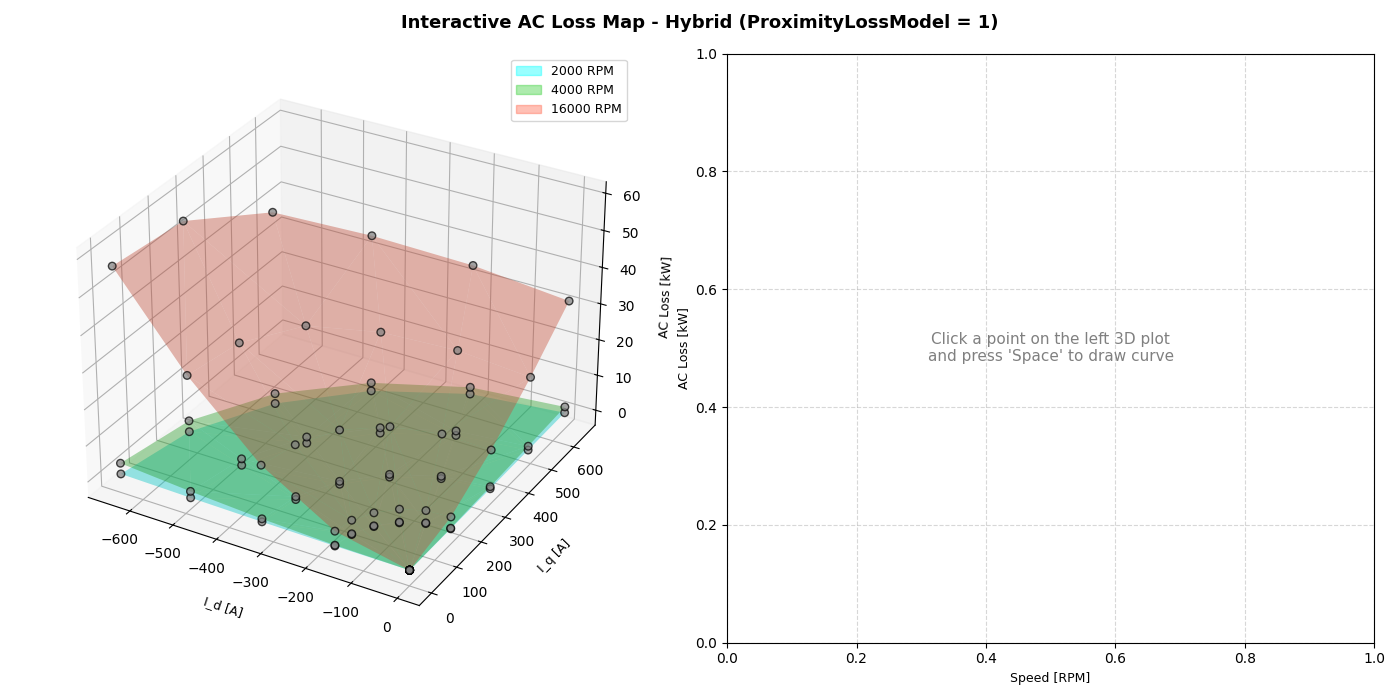

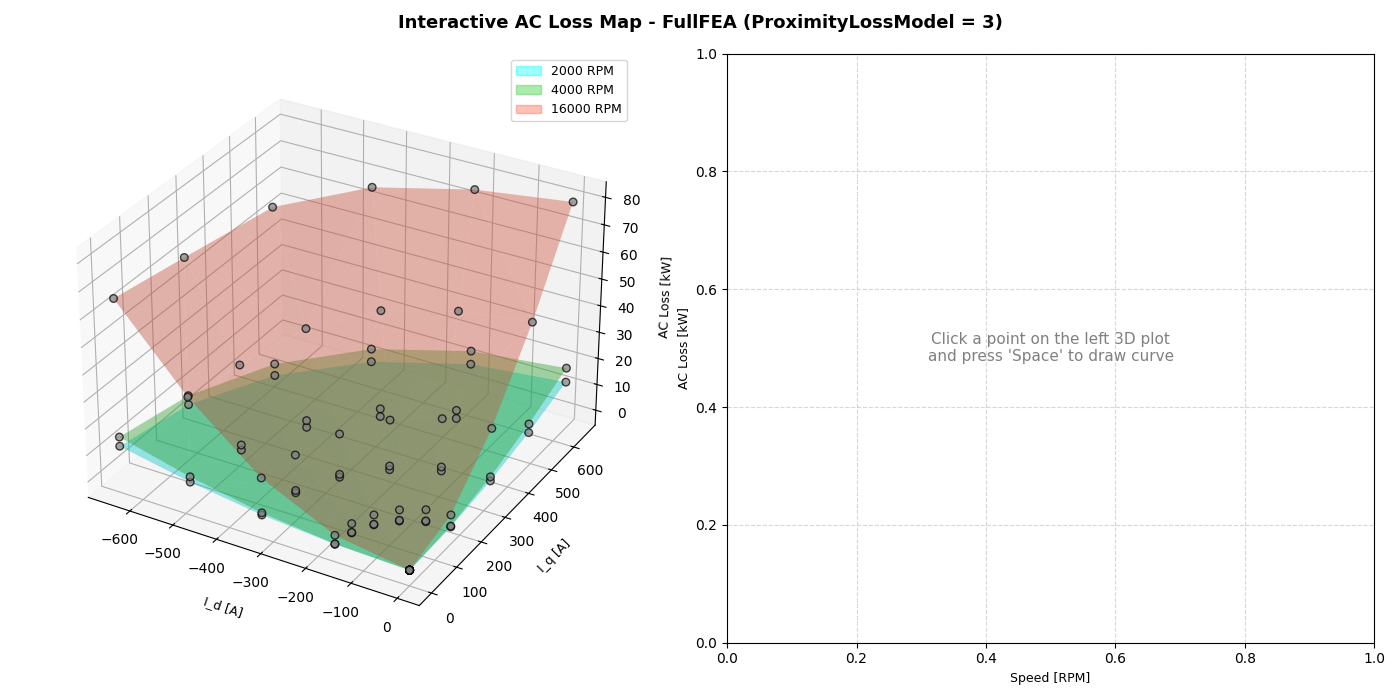

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [4] id-iq 평면 AC Active Only 손실 Surface 플롯 (Hybrid vs FullFEA 대화형 비교)
# ─────────────────────────────────────────────────────────────────────────────
# [Matplotlib 백엔드 설정]
# - 'auto'     : 환경 자동 감지 (VS Code -> widget, 브라우저 -> inline)
# - 'inline'   : 정적 이미지 출력 (웹 브라우저 JupyterLab에서 렌더링 에러 발생 시 이 값으로 설정하세요!)
# - 'widget'   : VS Code 및 JupyterLab용 대화형 플롯 (ipympl 필요)
# - 'notebook' : 클래식 Jupyter Notebook용 대화형 플롯 (nbagg)
PLOT_BACKEND = 'auto'  # <-- 브라우저에서 플롯이 안 뜨거나 렌더링 에러가 나면 'inline'으로 변경하고 다시 실행하세요!

import os
import sys


try:
    import IPython
    shell = IPython.get_ipython()
    if shell is not None:
        has_vscode_env = any(k.startswith('VSCODE_') for k in os.environ.keys())
        has_vscode_modules = any('vscode' in m.lower() for m in sys.modules.keys())
        
        # 1. 자동 감지 시 백엔드 결정
        selected_backend = PLOT_BACKEND
        if selected_backend == 'auto':
            if has_vscode_env and has_vscode_modules:
                selected_backend = 'widget'
            else:
                selected_backend = 'inline'
        
        print("--- Matplotlib Backend Config ---")
        print(f"  [Environment] VS Code Env={has_vscode_env}, VS Code Modules={has_vscode_modules}")
        print(f"  [Selection] Configured Mode='{PLOT_BACKEND}' -> Selected Backend='{selected_backend}'")
        
        # 2. 백엔드 적용
        if selected_backend == 'widget':
            shell.run_line_magic('matplotlib', 'widget')
            print("  -> Interactive backend 'widget' (ipympl) enabled.")
            print("  -> [Tip] 만약 웹 브라우저에서 'model not found' 등의 렌더링 에러가 발생하거나")
            print("           그래프가 표시되지 않는다면, 셀 맨 위의 PLOT_BACKEND = 'inline' 으로 변경 후 다시 실행하세요.")
        elif selected_backend == 'notebook':
            shell.run_line_magic('matplotlib', 'notebook')
            print("  -> Interactive backend 'notebook' (nbagg) enabled.")
        elif selected_backend == 'inline':
            shell.run_line_magic('matplotlib', 'inline')
            print("  -> Static backend 'inline' enabled (non-interactive).")
        else:
            shell.run_line_magic('matplotlib', 'inline')
            print(f"  -> Unknown backend '{selected_backend}', fallback to 'inline' enabled.")
except Exception as e:
    print(f"Failed to set matplotlib backend: {e}")

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

# 180포인트 결과가 sweep_results에 없으면 최신 JSON 파일 로드 시도
if 'sweep_results' not in globals() or not sweep_results:
    import glob
    from pathlib import Path
    import json
    
    json_files = sorted(glob.glob("map_exports/JEET_ACLoss_180Map_Summary_*.json"))
    if json_files:
        latest_json = json_files[-1]
        print(f"Loading latest sweep results from: {latest_json}")
        with open(latest_json, "r", encoding="utf-8") as f:
            sweep_results = json.load(f)
    else:
        print("Error: sweep_results not found in memory or map_exports!")
        sweep_results = []

if sweep_results:
    # 1. 데이터 분리 및 id, iq 변환
    hybrid_data = [p for p in sweep_results if p["proximity_model"] == 1]
    ts_data = [p for p in sweep_results if p["proximity_model"] == 3]
    
    def process_pts(pts, is_hybrid):
        speeds = np.array([p["speed"] for p in pts])
        currents = np.array([p["current"] for p in pts])
        phases = np.array([p["phase"] for p in pts])
        
        # dq 변환
        amplitude = currents * np.sqrt(2)
        phase_rad = (phases + 90) * np.pi / 180.0
        id_vals = amplitude * np.cos(phase_rad)
        iq_vals = amplitude * np.sin(phase_rad)
        
        if is_hybrid:
            losses = np.array([p["hybrid_total_kW"] for p in pts])
        else:
            losses = np.array([p["ts_ac_active_only_kW"] for p in pts])
            
        return speeds, id_vals, iq_vals, losses, pts

    # 속도별 뚜렷한 색상 설정 (2000: Cyan, 4000: LimeGreen, 16000: Tomato)
    speed_colors = {
        2000: 'cyan',
        4000: 'limegreen',
        8000: 'orange',
        16000: 'tomato'
    }
    default_colors = ['cyan', 'limegreen', 'tomato']
    
    def create_interactive_comparison_plot(pts_hybrid, pts_ts):
        speeds_h, id_h, iq_h, losses_h, raw_h = process_pts(pts_hybrid, is_hybrid=True)
        speeds_f, id_f, iq_f, losses_f, raw_f = process_pts(pts_ts, is_hybrid=False)
        
        currents_h = np.array([p["current"] for p in raw_h])
        phases_h = np.array([p["phase"] for p in raw_h])
        currents_f = np.array([p["current"] for p in raw_f])
        phases_f = np.array([p['phase'] for p in raw_f])
        
        unique_speeds = sorted(list(set(speeds_h)))
        
        # 3개 서브플롯 구성 (1행 3열: Hybrid 3D | FullFEA 3D | Comparison 2D)
        fig = plt.figure(figsize=(18, 5.5))
        fig.suptitle("AC Loss Comparison Map: Hybrid vs FullFEA (HalfSC Model)", fontsize=13, fontweight='bold')
        
        # Subplot 1: Hybrid 3D Map
        ax_left = fig.add_subplot(131, projection='3d')
        ax_left.set_title("Hybrid (ProximityLossModel = 1)", fontsize=11, fontweight='bold')
        
        # Subplot 2: FullFEA 3D Map
        ax_mid = fig.add_subplot(132, projection='3d')
        ax_mid.set_title("FullFEA (ProximityLossModel = 3)", fontsize=11, fontweight='bold')
        
        # 3D Surfaces 그리기
        legend_patches_h = []
        legend_patches_f = []
        
        for i, spd in enumerate(unique_speeds):
            idx_h = (speeds_h == spd)
            if np.any(idx_h):
                color = speed_colors.get(spd, default_colors[i % len(default_colors)])
                ax_left.plot_trisurf(id_h[idx_h], iq_h[idx_h], losses_h[idx_h], color=color, edgecolor='none', alpha=0.35)
                legend_patches_h.append(mpatches.Patch(color=color, alpha=0.35, label=f"{spd} RPM"))
                
            idx_f = (speeds_f == spd)
            if np.any(idx_f):
                color = speed_colors.get(spd, default_colors[i % len(default_colors)])
                ax_mid.plot_trisurf(id_f[idx_f], iq_f[idx_f], losses_f[idx_f], color=color, edgecolor='none', alpha=0.35)
                legend_patches_f.append(mpatches.Patch(color=color, alpha=0.35, label=f"{spd} RPM"))
                
        # 클릭용 Scatter 점 레이어
        sc_h = ax_left.scatter(id_h, iq_h, losses_h, c='grey', s=25, picker=True, pickradius=5, edgecolors='black', alpha=0.6)
        sc_f = ax_mid.scatter(id_f, iq_f, losses_f, c='grey', s=25, picker=True, pickradius=5, edgecolors='black', alpha=0.6)
        
        for ax, lp in [(ax_left, legend_patches_h), (ax_mid, legend_patches_f)]:
            ax.set_xlabel("I_d [A]", fontsize=8, labelpad=7)
            ax.set_ylabel("I_q [A]", fontsize=8, labelpad=7)
            ax.set_zlabel("AC Loss [kW]", fontsize=8, labelpad=7)
            ax.legend(handles=lp, fontsize=8, loc="upper right")
            
        # Subplot 3: 2D Comparison Curve
        ax_right = fig.add_subplot(133)
        ax_right.text(0.5, 0.5, "Click any point in left/middle 3D plots\nand press 'Space' to draw comparison curves", 
                     ha="center", va="center", fontsize=10, color="gray")
        ax_right.set_xlabel("Speed [RPM]", fontsize=9)
        ax_right.set_ylabel("AC Loss [kW]", fontsize=9)
        ax_right.grid(True, linestyle="--", alpha=0.5)
        
        # 공유 선택 상태 및 하이라이트 상태
        selected_pt = {"current": None, "phase": None, "id": None, "iq": None}
        highlights_h = []
        highlights_f = []
        
        # 양쪽 3D 플롯에 텍스트 안내 표시
        annotation_h = ax_left.text2D(0.02, 0.95, "", transform=ax_left.transAxes, 
                                      bbox=dict(boxstyle="round", fc="w", alpha=0.8), fontsize=8)
        annotation_f = ax_mid.text2D(0.02, 0.95, "", transform=ax_mid.transAxes, 
                                     bbox=dict(boxstyle="round", fc="w", alpha=0.8), fontsize=8)
        annotation_h.set_visible(False)
        annotation_f.set_visible(False)
        
        def on_pick(event):
            if event.artist not in [sc_h, sc_f]:
                return
            
            idx = event.ind[0]
            if event.artist == sc_h:
                curr = raw_h[idx]["current"]
                ph = raw_h[idx]["phase"]
            else:
                curr = raw_f[idx]["current"]
                ph = raw_f[idx]["phase"]
                
            selected_pt["current"] = curr
            selected_pt["phase"] = ph
            
            amp = curr * np.sqrt(2)
            phase_rad = (ph + 90) * np.pi / 180.0
            selected_pt["id"] = amp * np.cos(phase_rad)
            selected_pt["iq"] = amp * np.sin(phase_rad)
            
            # 이전 하이라이트 지우기
            for h in highlights_h + highlights_f:
                h.remove()
            highlights_h.clear()
            highlights_f.clear()
            
            # 양쪽 3D 플롯 모두 하이라이트 추가 (동일한 current/phase)
            same_h_idx = (currents_h == curr) & (phases_h == ph)
            hh = ax_left.scatter(id_h[same_h_idx], iq_h[same_h_idx], losses_h[same_h_idx], 
                                 color='red', s=70, edgecolors='black', linewidths=1.8, zorder=10)
            highlights_h.append(hh)
            
            same_f_idx = (currents_f == curr) & (phases_f == ph)
            hf = ax_mid.scatter(id_f[same_f_idx], iq_f[same_f_idx], losses_f[same_f_idx], 
                                color='red', s=70, edgecolors='black', linewidths=1.8, zorder=10)
            highlights_f.append(hf)
            
            # 텍스트 안내 박스 업데이트
            msg = (
                f"Selected Point:\n"
                f"I_rms: {curr:.1f} A, Phase: {ph:.1f} deg\n"
                f"Id: {selected_pt['id']:.1f} A, Iq: {selected_pt['iq']:.1f} A\n"
                f"→ Press 'Space' to compare"
            )
            for annot in [annotation_h, annotation_f]:
                annot.set_text(msg)
                annot.set_visible(True)
                
            fig.canvas.draw_idle()
            
        def on_key(event):
            if event.key != ' ':
                return
            if selected_pt["current"] is None:
                return
            
            ax_right.clear()
            
            curr = selected_pt["current"]
            ph = selected_pt["phase"]
            
            curve_speeds = []
            curve_losses_h = []
            curve_losses_f = []
            
            # Hybrid와 FullFEA 결과 비교 매칭
            for spd in unique_speeds:
                match_h = [p for p in raw_h if p["speed"] == spd and np.isclose(p["current"], curr) and np.isclose(p["phase"], ph)]
                match_f = [p for p in raw_f if p["speed"] == spd and np.isclose(p["current"], curr) and np.isclose(p["phase"], ph)]
                if match_h and match_f:
                    curve_speeds.append(spd)
                    curve_losses_h.append(match_h[0]["hybrid_total_kW"])
                    curve_losses_f.append(match_f[0]["ts_ac_active_only_kW"])
            
            # 두 곡선 겹쳐 그리기
            ax_right.plot(curve_speeds, curve_losses_h, marker='o', linestyle='-', color='dodgerblue', linewidth=2, label="Hybrid AC Total")
            ax_right.plot(curve_speeds, curve_losses_f, marker='*', linestyle='--', color='crimson', linewidth=2, label="FullFEA AC Active Only")
            
            # 수치 텍스트 표시
            for xs, yh, yf in zip(curve_speeds, curve_losses_h, curve_losses_f):
                ax_right.annotate(f"{yh:.2f}", xy=(xs, yh), xytext=(4, 4), textcoords="offset points", fontsize=8, color="dodgerblue")
                ax_right.annotate(f"{yf:.2f}", xy=(xs, yf), xytext=(4, -12), textcoords="offset points", fontsize=8, color="crimson")
                
            ax_right.set_title(f"AC Loss vs Speed Comparison\n(I_rms={curr:.1f} A, Phase={ph:.1f} deg)", fontsize=11, fontweight='bold')
            ax_right.set_xlabel("Speed [RPM]", fontsize=9)
            ax_right.set_ylabel("AC Loss [kW]", fontsize=9)
            ax_right.grid(True, linestyle="--", alpha=0.5)
            ax_right.legend(fontsize=9, loc="upper left")
            
            fig.canvas.draw_idle()
            
        fig.canvas.mpl_connect('pick_event', on_pick)
        fig.canvas.mpl_connect('key_press_event', on_key)
        plt.tight_layout()
        plt.show()
        
    if len(hybrid_data) > 0 and len(ts_data) > 0:
        create_interactive_comparison_plot(hybrid_data, ts_data)
    else:
        print("Error: Need both Hybrid and FullFEA data in sweep results to build comparison plot.")
else:
    print("No sweep results found to plot.")
